This notebook is the second part of the image captioning project.

In this notebook I load the trained model and use it to generate captions for images.

The main required function is:

```python
def generate_caption(image_path: str, model: any) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """

In [1]:
import os
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
PyTorch version: 2.10.0+cpu
CUDA available: False


## Setting Up the Inference Environment

First I initialize the random seed, select the available device (CPU or GPU) and define the paths to the saved model files.
The trained model, vocabulary, and configuration created in the training notebook will be loaded in the following steps.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

MODEL_DIR = "models"

# Prefer best model if it exists, otherwise use final model
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_caption_model.pth")
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "final_caption_model.pth")

if os.path.exists(BEST_MODEL_PATH):
    MODEL_PATH = BEST_MODEL_PATH
else:
    MODEL_PATH = FINAL_MODEL_PATH

WORD_TO_IDX_PATH = os.path.join(MODEL_DIR, "word_to_idx.pkl")
IDX_TO_WORD_PATH = os.path.join(MODEL_DIR, "idx_to_word.pkl")
CONFIG_PATH = os.path.join(MODEL_DIR, "improved_config.json")

print("Model path:", MODEL_PATH)

Using device: cpu
Model path: models\improved_caption_model.pth


In [3]:
required_files = [
    MODEL_PATH,
    WORD_TO_IDX_PATH,
    IDX_TO_WORD_PATH,
    CONFIG_PATH
]

for file_path in required_files:
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Missing required file: {file_path}. "
            "Run data_and_training.ipynb first so the model artifacts are saved."
        )

print("All saved model files found.")
print(os.listdir(MODEL_DIR))

All saved improved model files found.
['caption_model.pth', 'config.json', 'idx_to_word.pkl', 'improved_caption_model.pth', 'improved_config.json', 'word_to_idx.pkl']


## Loading the Saved Model Files

The vocabulary, configuration and trained model are loaded from disk.

These files contain everything required for inference, including the model architecture, vocabulary mappings and caption generation settings

In [4]:
with open(WORD_TO_IDX_PATH, "rb") as f:
    word_to_idx = pickle.load(f)

with open(IDX_TO_WORD_PATH, "rb") as f:
    idx_to_word = pickle.load(f)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

FEATURE_SIZE = config["feature_size"]
EMBED_SIZE = config["embed_size"]
HIDDEN_SIZE = config["hidden_size"]
NUM_LAYERS = config["num_layers"]
VOCAB_SIZE = config["vocab_size"]
MAX_CAPTION_LENGTH = config["max_caption_length"]

PAD_IDX = config["pad_idx"]
START_IDX = config["start_idx"]
END_IDX = config["end_idx"]
UNK_IDX = config["unk_idx"]

print("Vocabulary size:", VOCAB_SIZE)
print("Maximum caption length:", MAX_CAPTION_LENGTH)

Vocabulary size: 3673
Maximum caption length: 20


In [5]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformation is ready.")

Image transformation is ready.


## Loading the Saved Model Files

The vocabulary, configuration and trained model are loaded from disk.

these files contain everything required for inference, including the model architecture, vocabulary mappings and caption generation settings.

In [6]:
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super(ResNetFeatureExtractor, self).__init__()

        try:
            weights = models.ResNet18_Weights.DEFAULT
            resnet = models.resnet18(weights=weights)
            print("Using pretrained ResNet18 weights.")
        except Exception as e:
            raise RuntimeError(
                "Pretrained ResNet18 weights could not be loaded. "
                "Please connect to the internet once or make sure the weights are cached locally."
            )

        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)

        for param in self.resnet.parameters():
            param.requires_grad = False

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
            features = features.view(features.size(0), -1)
        return features


class ImprovedCaptionModel(nn.Module):
    def __init__(self, feature_size, embed_size, hidden_size, vocab_size, num_layers=1):
        super(ImprovedCaptionModel, self).__init__()

        self.feature_fc = nn.Linear(feature_size, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.embed = nn.Embedding(vocab_size, embed_size)

        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, image_features, caption_inputs):
        image_embeddings = self.feature_fc(image_features)
        image_embeddings = self.relu(image_embeddings)
        image_embeddings = self.dropout(image_embeddings)
        image_embeddings = image_embeddings.unsqueeze(1)

        word_embeddings = self.embed(caption_inputs)
        lstm_inputs = torch.cat([image_embeddings, word_embeddings], dim=1)

        lstm_outputs, _ = self.lstm(lstm_inputs)
        outputs = self.fc(lstm_outputs)

        return outputs

## Loading the Trained Model

The saved model weights are loaded into the recreated network.

After loading, the model is switched to evaluation mode so that it can generate captions without updating its parameters

In [7]:
feature_extractor = ResNetFeatureExtractor().to(device)
feature_extractor.eval()

checkpoint = torch.load(MODEL_PATH, map_location=device)

model = ImprovedCaptionModel(
    feature_size=checkpoint["feature_size"],
    embed_size=checkpoint["embed_size"],
    hidden_size=checkpoint["hidden_size"],
    vocab_size=checkpoint["vocab_size"],
    num_layers=checkpoint["num_layers"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Improved trained model loaded successfully.")

Using pretrained ResNet18 weights.
Improved trained model loaded successfully.


## Caption Generation Function

This function generates a caption for a single image.

The image is first converted into a feature vector using the pretrained ResNet18 encoder. The LSTM decoder then predicts one word at a time until it reaches the end token or the maximum caption length.
The generated words are combined to produce the final caption.

In [8]:
def generate_caption(image_path: str, model: any) -> str:
    """
    takes a path to an image and returns a generated caption string
    """
    model.eval()
    feature_extractor.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = image_transform(image).unsqueeze(0).to(device)

    generated_words = []

    with torch.no_grad():
        image_feature = feature_extractor(image_tensor)

        image_embedding = model.feature_fc(image_feature)
        image_embedding = model.relu(image_embedding)
        image_embedding = model.dropout(image_embedding)
        image_embedding = image_embedding.unsqueeze(1)

        lstm_output, hidden = model.lstm(image_embedding)

        current_word = torch.tensor([[START_IDX]], dtype=torch.long).to(device)

        for _ in range(MAX_CAPTION_LENGTH):
            word_embedding = model.embed(current_word)
            lstm_output, hidden = model.lstm(word_embedding, hidden)
            output = model.fc(lstm_output.squeeze(1))

            predicted_idx = output.argmax(dim=1).item()

            if predicted_idx == END_IDX:
                break

            if predicted_idx not in [PAD_IDX, START_IDX, UNK_IDX]:
                generated_words.append(idx_to_word[predicted_idx])

            current_word = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)

    if len(generated_words) == 0:
        return "No caption generated."

    return " ".join(generated_words)

In [9]:
DATA_DIR = "caption_data_extracted"

image_extensions = {".jpg", ".jpeg", ".png"}

all_image_paths = []
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if Path(file).suffix.lower() in image_extensions:
            all_image_paths.append(os.path.join(root, file))

print("Images found:", len(all_image_paths))

if len(all_image_paths) == 0:
    raise FileNotFoundError("No images found. Make sure caption_data_extracted exists.")

Images found: 8091


## Loading Human Captions

The original captions from the dataset are loaded again.

These captions are not used by the model during inference. Instead they are displayed only to compare the generated caption with the human-written descriptions.

In [10]:
caption_file = None

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if "caption" in file.lower() and file.lower().endswith((".txt", ".csv")):
            caption_file = os.path.join(root, file)
            break

if caption_file is None:
    raise FileNotFoundError("Caption file was not found.")

print("Using caption file:", caption_file)


def load_captions_for_inference(caption_file):
    rows = []

    with open(caption_file, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    lines = [line.strip() for line in lines if line.strip()]

    if lines[0].lower().replace(" ", "") in ["image,caption", "image_name,caption", "filename,caption"]:
        lines = lines[1:]

    for line in lines:
        image_name = None
        caption = None

        if "#" in line and ("jpg" in line.lower() or "png" in line.lower()):
            parts = line.split(maxsplit=1)
            if len(parts) == 2:
                image_name = parts[0].split("#")[0]
                caption = parts[1]

        elif "\t" in line:
            parts = line.split("\t")
            if len(parts) >= 2:
                image_name = parts[0].strip()
                caption = " ".join(parts[1:]).strip()

        elif "," in line:
            parts = line.split(",", 1)
            if len(parts) == 2:
                image_name = parts[0].strip()
                caption = parts[1].strip()

        if image_name is not None and caption is not None:
            rows.append({
                "image": image_name,
                "caption": caption
            })

    return pd.DataFrame(rows)


captions_df = load_captions_for_inference(caption_file)

print("Captions loaded:", len(captions_df))
print("Unique images:", captions_df["image"].nunique())
captions_df.head()

Using caption file: caption_data_extracted\captions.txt
Captions loaded: 40455
Unique images: 8103


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## Testing the Model on Images

Finally the trained model is tested on several images from the dataset.

For each image, the notebook displays:
the image
the generated caption
the original human-written captions

This comparison makes it easier to evaluate both successful predictions and cases where the model produces inaccurate or incomplete captions

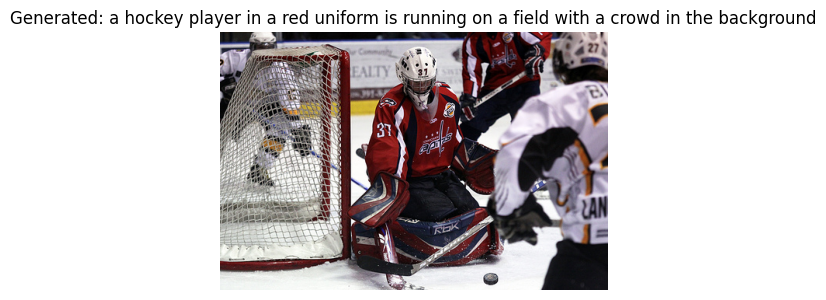

Image: 3354489242_dd529ffa1f.jpg
Generated caption: a hockey player in a red uniform is running on a field with a crowd in the background

Human captions:
- A goalie tries to block the puck in a hockey game .
- A hockey goalie stops the puck .
- People playing hockey .
- Several hockey players move toward the puck next to a goal .
- Two hockey teams compete .
----------------------------------------------------------------------------------------------------


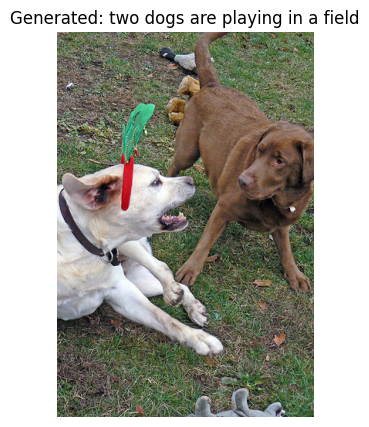

Image: 2071309418_1d7580b0f0.jpg
Generated caption: two dogs are playing in a field

Human captions:
- A white dog wearing a christmas reindeer headband plays with a brown dog in the grass among some stuffed animals .
- A white dog wearing reindeer ears is next to a brown dog .
- A white dog with fake antlers on its head and a brown dog play together outdoors .
- The white dog next to the brown dog is wearing a christmas headband .
- "Two dogs , one wearing christmas antlers , tussle on the grass ."
----------------------------------------------------------------------------------------------------


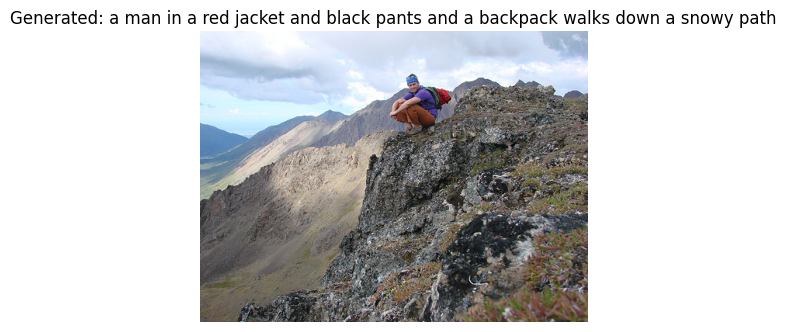

Image: 1247181182_35cabd76f3.jpg
Generated caption: a man in a red jacket and black pants and a backpack walks down a snowy path

Human captions:
- a man sits on a rock .
- A man sitting on a cliff in the mountains .
- A man wearing a blue shirt crouches on a rocky cliff .
- A person posing on a mountaintop .
- The man is sitting at the top of a rocky mountain .
----------------------------------------------------------------------------------------------------


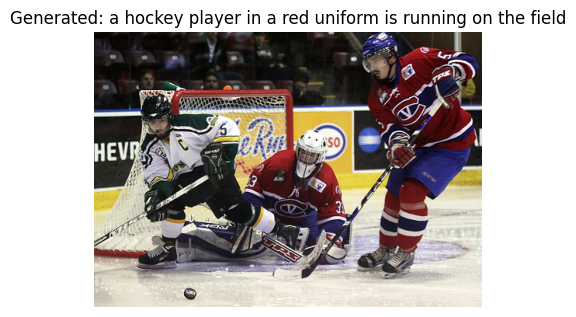

Image: 3523950181_414978964e.jpg
Generated caption: a hockey player in a red uniform is running on the field

Human captions:
- A goalie is covering his net while two other hockey players chase after the hockey puck .
- A group of hockey players around a goal .
- Men play hockey .
- The hockey players move quickly towards the puck .
- Three hockey players are engaged in a game .
----------------------------------------------------------------------------------------------------


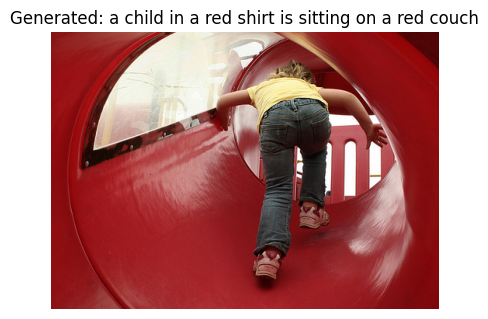

Image: 2554570943_122da6438f.jpg
Generated caption: a child in a red shirt is sitting on a red couch

Human captions:
- A child climbs up the inside of a red tube in a play structure .
- A child in a yellow shirt and blue jeans climbs through a red playground tunnel .
- A girl climbs through a red plastic tunnel on a playground .
- a girl climbs up a red slide .
- Child climbs the inside of a red slide .
----------------------------------------------------------------------------------------------------


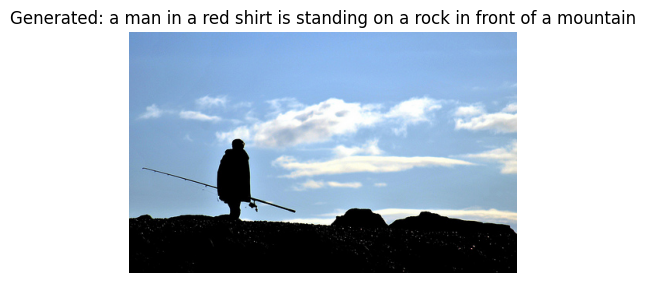

Image: 2472250097_a3191a94b3.jpg
Generated caption: a man in a red shirt is standing on a rock in front of a mountain

Human captions:
- A man carrying a fishing pole silhouetted against a bright blue sky .
- A person stands on a hill surrounded by blue skies and clouds .
- A person with a fishing pole is backlit against a blue cloudy sky .
- A person with a fishing pole silhouetted in front of a blue sky .
- A silhouette of a man with a fishing pole .
----------------------------------------------------------------------------------------------------


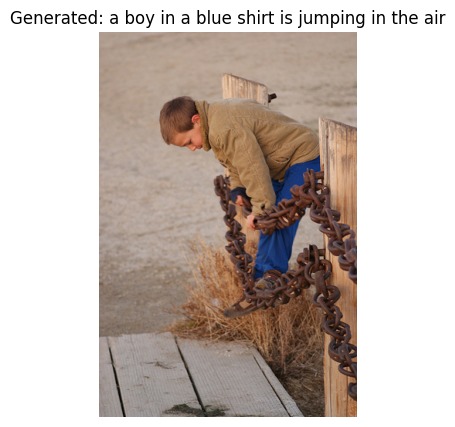

Image: 2419591925_1038c6c570.jpg
Generated caption: a boy in a blue shirt is jumping in the air

Human captions:
- A boy in a brown jacket is standing on chains between two wooden posts .
- A child standing on a heavy chain fence at a dock .
- A little boy climbing over a chain fence .
- A little boy standing and playing on a chained fence .
- Boy climbing on a chain fence .
----------------------------------------------------------------------------------------------------


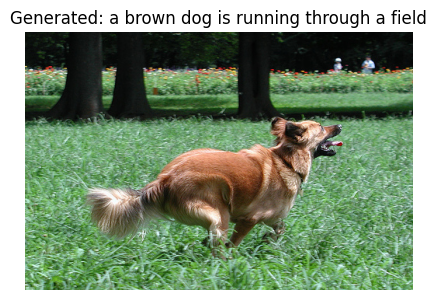

Image: 2180480870_dcaf5ac0df.jpg
Generated caption: a brown dog is running through a field

Human captions:
- A brown dog is about to jump .
- A dog runs through the grass .
- a little brown dog running through a field of grass
- Tan dog running through long grass in a park-like setting .
- "The large , brownish dog is running through a grassy area ."
----------------------------------------------------------------------------------------------------


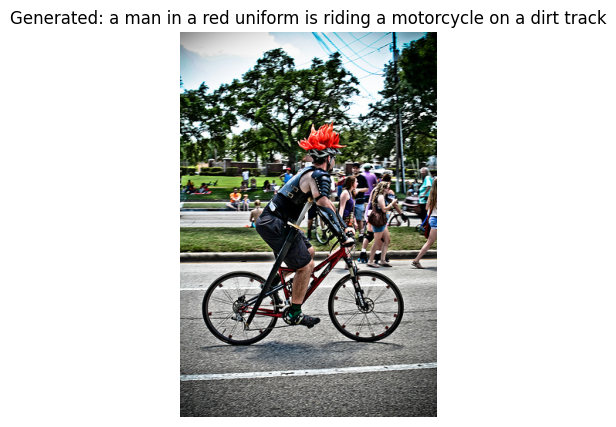

Image: 3517023411_a8fbd15230.jpg
Generated caption: a man in a red uniform is riding a motorcycle on a dirt track

Human captions:
- A biker is racing to keep up with the runners
- a biker rides down the street .
- A man on a red bicycle rides past several pedestrians .
- A man with something orange on his helmet riding a bike in a busy setting .
- Man rides on bicycle as other people walk .
----------------------------------------------------------------------------------------------------


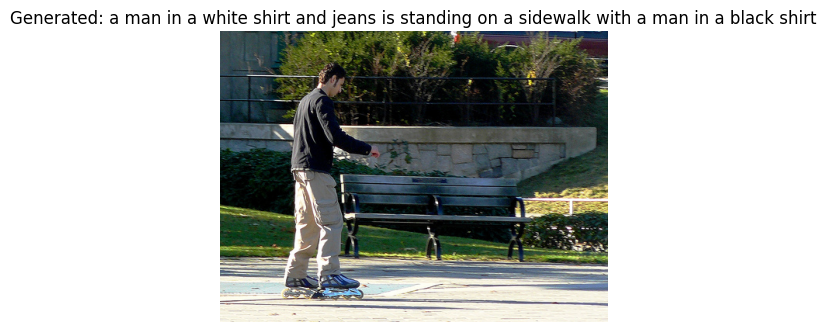

Image: 2029280005_a19609c81a.jpg
Generated caption: a man in a white shirt and jeans is standing on a sidewalk with a man in a black shirt

Human captions:
- a man in a black shirt is rollerblading past a bench in the city .
- A man is inline skating in front of a wooden bench .
- A man is wearing Rollerblades standing on a paved area near a park bench .
- A man on Rollerblades travelling down the sidewalk .
- A man wearing a black shirt and brown pants skates on a concrete surface near a park bench .
----------------------------------------------------------------------------------------------------


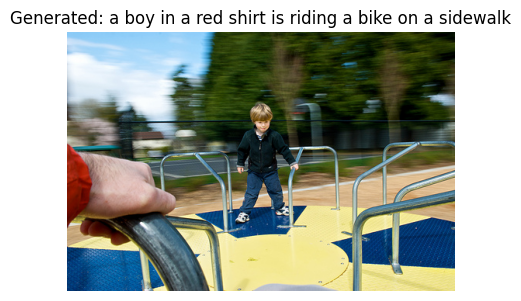

Image: 3421789737_f625dd17ed.jpg
Generated caption: a boy in a red shirt is riding a bike on a sidewalk

Human captions:
- A boy spinning on a blue and yellow merry-go-round .
- a child on a spinning wheel holding on for dear life
- A young boy rides a blue and yellow merry-go-round with an adult male hand in the foreground .
- A young kid is standing up on the merry go round .
- The boy is standing on the playground equipment in the blue triangle .
----------------------------------------------------------------------------------------------------


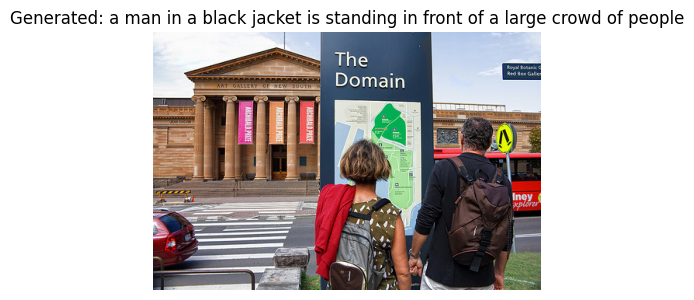

Image: 3523471597_87e0bf3b21.jpg
Generated caption: a man in a black jacket is standing in front of a large crowd of people

Human captions:
- A couple are looking at an area map .
- "A man and woman are standing in front of an art gallery , looking at a map ."
- Tourists examine a sign .
- Two people are reading a sign in front of a museum .
- Two people read a sign in front of a museum .
----------------------------------------------------------------------------------------------------


In [11]:
sample_paths = random.sample(all_image_paths, min(8, len(all_image_paths)))

for image_path in sample_paths:
    image_name = os.path.basename(image_path)
    image = Image.open(image_path).convert("RGB")
    generated = generate_caption(image_path, model)

    human_captions = captions_df[captions_df["image"] == image_name]["caption"].tolist()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Generated: " + generated)
    plt.show()

    print("Image:", image_name)
    print("Generated caption:", generated)
    print("\nHuman captions:")

    for cap in human_captions[:5]:
        print("-", cap)

    print("-" * 100)

## Result Analysis

The model can generate reasonable captions for some images, especially when the image contains common objects such as people, dogs, bicycles, or outdoor scenes. In successful examples, the generated caption usually captures the main object or general scene correctly.

However, the model also has failure cases. Some captions are too generic or describe the wrong object/action. This is expected because the model uses a relatively simple ResNet18 encoder and LSTM decoder, and the decoder uses greedy word selection. The model learns general visual-language patterns, but it does not always understand fine details in the image.

Overall, the inference notebook shows that the saved model can be loaded correctly and used to generate captions for image paths.